## Zomato Restaurant Data Analysis using Python

### UNDERSTANDING THE DATA (Ch.4)
#### Step 1: Importing necessary Python libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Step 2: Loading Dataset and Creating the data frame.
*   Creating the data frame.
*   display all column names.
*   setting pandas display option to display all columns.
*   display random few lines of data.

In [2]:
df = pd.read_csv(r'dataset\zomato-data.csv')
print(df.columns)
pd.set_option('display.max_columns', None)
print(df.sample(5))


Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')
                            name online_order book_table   rate  votes  \
39  Maruthi Davangere Benne Dosa          Yes         No  4.0/5   17.0   
18                      T3H Cafe           No         No  3.9/5   93.0   
73                      LSD Cafe           No         No  2.9/5   84.0   
33               Ovenstory Pizza          Yes         No  3.9/5  172.0   
96                        Kaggis           No         No  3.8/5   64.0   

    approx_cost(for two people) listed_in(type)  
39                        150.0          Dining  
18                        300.0           Cafes  
73                        700.0           other  
33                        750.0          Dining  
96                        250.0          Dining  


#### Step 3: Dataset Structure 
*   Getting shape of data using df.shape()
*   Getting summary of the dataframe using df.info() 

In [4]:
print("Shape of dataset:",df.shape)
print("----------Dataset summary------------------")
df.info()

Shape of dataset: (148, 7)
----------Dataset summary------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    object 
 4   votes                        144 non-null    float64
 5   approx_cost(for two people)  145 non-null    float64
 6   listed_in(type)              148 non-null    object 
dtypes: float64(2), object(5)
memory usage: 8.2+ KB


This helps identify:
*	Number of rows and columns
*	Data types
*	Missing values


### UNDERSTANDING SPREAD OF DATA (Ch.5)
#### Step 1: Visualize the spread of 'rate' using a Histogram
With our dataset we have used histogram with “kde=True” to understand the distribution and spread of data in column “rate” (user ratings). 

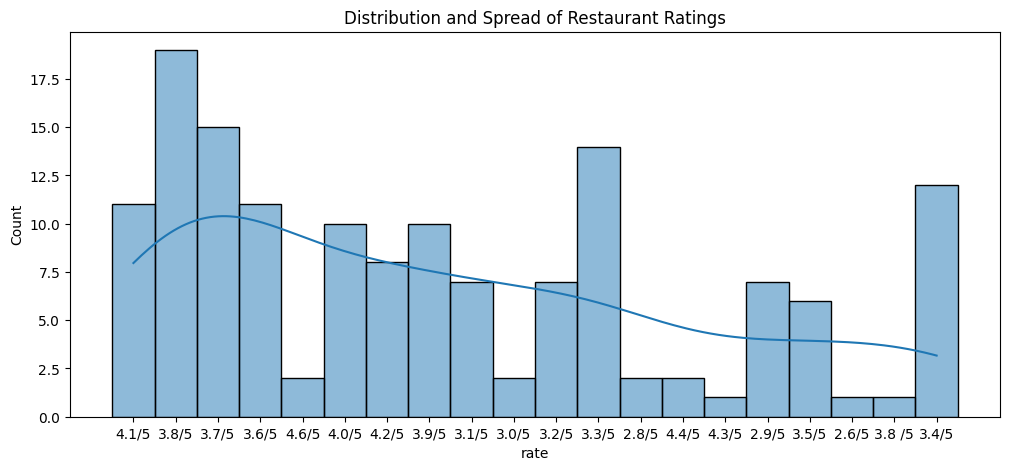

In [5]:
plt.figure(figsize=(12, 5))
sns.histplot(df['rate'], bins=10, kde=True)
plt.title("Distribution and Spread of Restaurant Ratings")
plt.show()

#### Step 2: Convert the rate column to a float by removing denominator characters.

Data Cleaning and Preparation

df['rate']=df['rate'].apply(handleRate):
Applies the handleRate function to clean and convert each rating value in the
'rate' column.

In [6]:
def handleRate(value):
    value=str(value).split('/')
    value=value[0];
    return float(value)

df['rate']=df['rate'].apply(handleRate)

print("----------After cleaning rate column, printing top few records")
print(df[['name','rate']].head())

----------After cleaning rate column, printing top few records
                    name  rate
0                  Jalsa   4.1
1         Spice Elephant   4.1
2        San Churro Cafe   3.8
3  Addhuri Udupi Bhojana   3.7
4          Grand Village   3.8


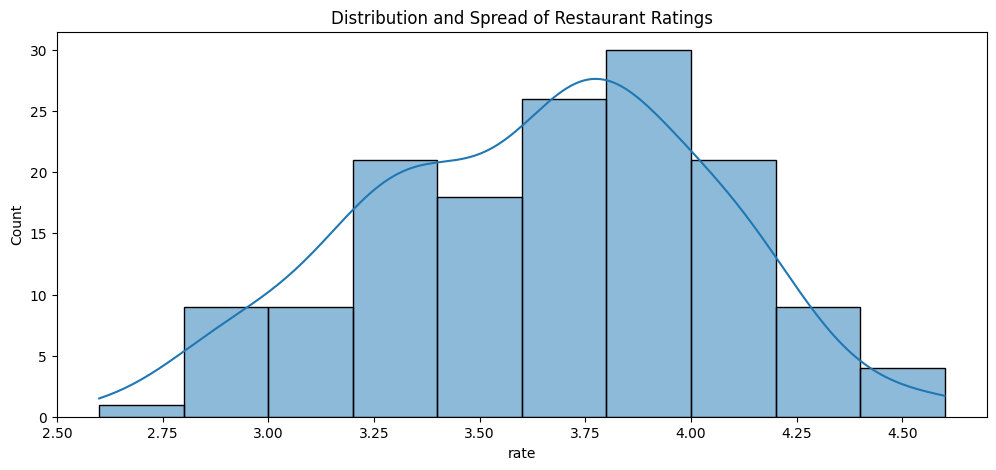

In [7]:
plt.figure(figsize=(12, 5))
sns.histplot(df['rate'], bins=10, kde=True)
plt.title("Distribution and Spread of Restaurant Ratings")
plt.show()

## Automated EDA

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    object 
 4   votes                        144 non-null    float64
 5   approx_cost(for two people)  145 non-null    float64
 6   listed_in(type)              148 non-null    object 
dtypes: float64(2), object(5)
memory usage: 8.2+ KB


,votes,approx_cost(for two people)
count,144.000000,145.000000
mean,265.729167,415.517241
std,662.490314,221.697777
min,0.000000,100.000000
25%,6.000000,200.000000
50%,39.000000,400.000000
75%,205.500000,600.000000
max,4884.000000,950.000000


AUTO REPORTING

In [3]:
#%pip install ydata-profiling

from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="EDA Report")
profile.to_file("report.html")



Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:00<00:00, 205.88it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# pip install sweetviz
import sweetviz as sv
import pandas as pd

report = sv.analyze(df)
report.show_html('sweetviz_report.html')




                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [14]:
# pip install eda-report
from eda_report.summarize import summarize

# Creates a Word document report
summarize('data.csv')


ModuleNotFoundError: No module named 'eda_report'

## Data Cleaning

In [38]:

def handle_rate(val):
    return float(str(val).split('/')[0])

df['rate'] = df['rate'].apply(handle_rate)
df.fillna(df.mean(numeric_only=True), inplace=True)
df.sample(5)


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
29,Srinathji's Cafe,No,No,3.8,265.729167,550.0,Cafes
0,Jalsa,Yes,Yes,4.1,775.000000,800.0,Buffet
17,Kirthi's Biryani,Yes,No,3.8,144.000000,700.0,Cafes
105,Cakes & Slices,No,No,3.5,13.000000,300.0,Dining
20,The Vintage Cafe,Yes,No,3.0,62.000000,400.0,Cafes


## Visualization

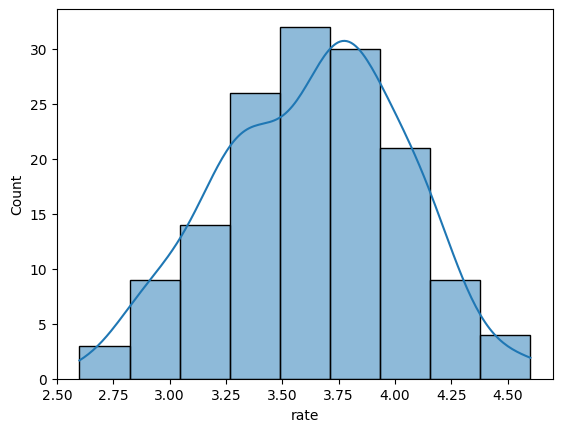

In [39]:
sns.histplot(df['rate'], kde=True)
plt.show()

In [8]:
sns.countplot(x='listed_in(type)', data=df)
plt.title("Restaurant Types")
plt.xlabel("Restaurant Type")
plt.ylabel("Count")
plt.show()




C:\Users\Hitesh\AppData\Local\Temp\ipykernel_18776\41782438.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Regression Model

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df['online_order'] = df['online_order'].map({'Yes':1,'No':0})
X = df[['votes','approx_cost(for two people)','online_order']]
y = df['rate']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)

print("MSE:",mean_squared_error(y_test,pred))
print("MAE:",mean_absolute_error(y_test,pred))
print("R2:",r2_score(y_test,pred))


## Classification

In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

df['rating_class'] = df['rate'].apply(lambda x: 1 if x>=4 else 0)
X = df[['votes','approx_cost(for two people)','online_order']]
y = df['rating_class']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
clf = LogisticRegression()
clf.fit(X_train,y_train)
pred = clf.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))
print(confusion_matrix(y_test,pred))
